In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# palette="pastel"
# palette="muted"
# palette="bright"
# palette="deep"
# palette="Set1"
# palette="Set2"
# palette="Set3"

# "YlOrRd"
# "Blues"
# "Greens"
# "Purples"
# "viridis"
# "plasma"
# "inferno"

In [ ]:
#Load Data
def load_data():
    data = "cb_data.csv"
    df = pd.read_csv(data)
    return df




#Sex Ratio 
def sex_ratio():
    data = load_data()

    male = data["sex_male"].mean() * 100
    female = 100 - male

    # Create the response
    ratio = f"Ratio is {male:.1f}% Male and {female:.1f}% Female."

    # Return the response
    return ratio




#Age Distrobution Chart
def age_distribution():
    data = load_data()

    age_counts = data["age_range"].value_counts()

    order = [
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]

    age_counts = age_counts.reindex(order, fill_value=0)

    # Smaller figure
    plt.figure(figsize=(7, 4.5))

    # Colorful bars
    ax = sns.barplot(
        x=age_counts.index,
        y=age_counts.values,
        hue=age_counts.index,
        palette="Set2",
        legend=False
    )

    ax.set_title(
        "Age Distribution",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("Age Range", fontsize=11)
    ax.set_ylabel("Number of People", fontsize=11)

    # Y-axis increments of 10
    max_count = age_counts.max()
    ax.set_yticks(range(0, max_count + 10, 10))

    # Numbers above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%d",
            padding=2,
            fontsize=9
        )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return age_counts




#Heat Map Creator to tell how many people com in per day of week
def day_of_week_heatmap():
    data = load_data()

    # Count how many people came in on each day
    day_counts = data["day_of_week"].value_counts()

    # Put days in the correct order
    order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    day_counts = day_counts.reindex(order, fill_value=0)

    # Create data for the heatmap
    heatmap_data = pd.DataFrame(
        [day_counts.values],
        columns=day_counts.index
    )

    plt.figure(figsize=(8, 2.5))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap= "YlOrRd"
    )

    plt.title("People by Day of Week")
    plt.xlabel("Day of Week")
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

    return day_counts




def age_day_heatmap():
    data = load_data()

    # Order for the age ranges
    age_order = [
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]

    # Order for the days
    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    # Count customers by age range and day
    heatmap_data = pd.crosstab(
        data["age_range"],
        data["day_of_week"]
    )

    # Make sure everything is in the correct order
    heatmap_data = heatmap_data.reindex(
        index=age_order,
        columns=day_order,
        fill_value=0
    )

    # Create heatmap
    plt.figure(figsize=(9, 5))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlOrRd"
    )

    plt.title(
        "Customers by Age Range and Day",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Day of Week")
    plt.ylabel("Age Range")

    plt.tight_layout()
    plt.show()

    return heatmap_data




def age_day_sex_heatmap():
    data = load_data()

    age_order = [
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]

    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    # Male customers
    male_data = pd.crosstab(
        data.loc[data["sex_male"] == True, "age_range"],
        data.loc[data["sex_male"] == True, "day_of_week"]
    ).reindex(index=age_order, columns=day_order, fill_value=0)

    # Female customers
    female_data = pd.crosstab(
        data.loc[data["sex_male"] == False, "age_range"],
        data.loc[data["sex_male"] == False, "day_of_week"]
    ).reindex(index=age_order, columns=day_order, fill_value=0)

    # Male heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        male_data,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("Male Customers by Age and Day")
    plt.xlabel("Day of Week")
    plt.ylabel("Age Range")
    plt.tight_layout()
    plt.show()

    # Female heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        female_data,
        annot=True,
        fmt="d",
        cmap="Reds"
    )

    plt.title("Female Customers by Age and Day")
    plt.xlabel("Day of Week")
    plt.ylabel("Age Range")
    plt.tight_layout()
    plt.show()




def age_day_sex_heatmap():
    data = load_data()

    age_order = [
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]

    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    # Male customers
    male_data = pd.crosstab(
        data.loc[data["sex_male"] == True, "age_range"],
        data.loc[data["sex_male"] == True, "day_of_week"]
    ).reindex(index=age_order, columns=day_order, fill_value=0)

    # Female customers
    female_data = pd.crosstab(
        data.loc[data["sex_male"] == False, "age_range"],
        data.loc[data["sex_male"] == False, "day_of_week"]
    ).reindex(index=age_order, columns=day_order, fill_value=0)

    # Male heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        male_data,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("Male Customers by Age and Day")
    plt.xlabel("Day of Week")
    plt.ylabel("Age Range")
    plt.tight_layout()
    plt.show()

    # Female heatmap
    plt.figure(figsize=(9, 5))
    sns.heatmap(
        female_data,
        annot=True,
        fmt="d",
        cmap="Reds"
    )

    plt.title("Female Customers by Age and Day")
    plt.xlabel("Day of Week")
    plt.ylabel("Age Range")
    plt.tight_layout()
    plt.show()



In [41]:
load_data()

,day_of_week,arrival_time,age_range,sex_male,content_purchased,attire_casual,attire_type,occupation,dine_in,device_type
0,Friday,12:57,10-19,False,iced_drink,True,unemployed,False,NaN,NaN
1,Friday,13:02,20-29,True,pastry,True,pajamas,retail,True,phone
2,Friday,14:14,60-69,True,dessert,True,fashion_casual,business,True,NaN
3,Friday,14:15,60-69,False,NaN,True,fashion_casual,business,True,NaN
4,Friday,14:16,30-39,True,NaN,True,streetwear,NaN,True,NaN
5,Friday,14:17,50-59,False,NaN,True,streetwear,NaN,True,NaN


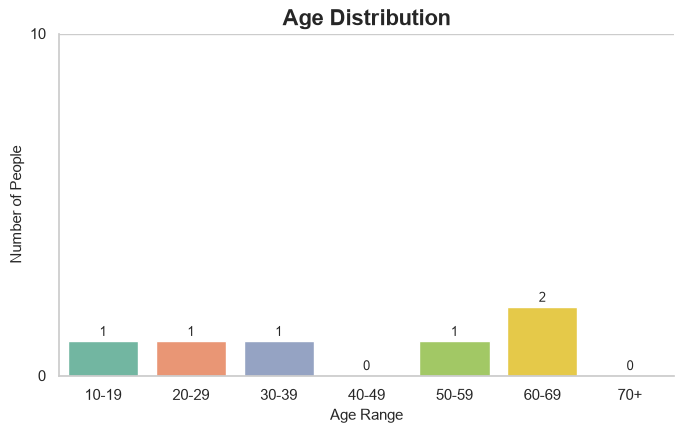

age_range
10-19    1
20-29    1
30-39    1
40-49    0
50-59    1
60-69    2
70+      0
Name: count, dtype: int64

In [70]:
age_distribution()

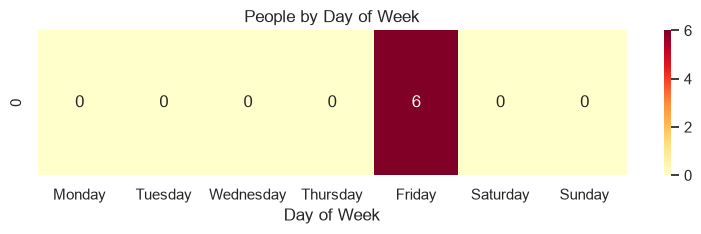

day_of_week
Monday       0
Tuesday      0
Wednesday    0
Thursday     0
Friday       6
Saturday     0
Sunday       0
Name: count, dtype: int64

In [71]:
day_of_week_heatmap()

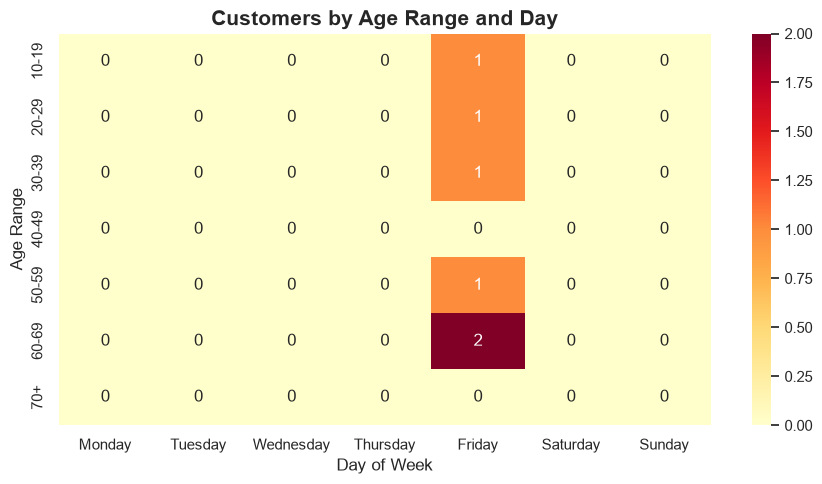

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
age_range,,,,,,,
10-19,0,0,0,0,1,0,0
20-29,0,0,0,0,1,0,0
30-39,0,0,0,0,1,0,0
40-49,0,0,0,0,0,0,0
50-59,0,0,0,0,1,0,0
60-69,0,0,0,0,2,0,0
70+,0,0,0,0,0,0,0


In [74]:
age_day_heatmap()